# KYC — Étape 2.1 : Détection de champs sur documents d'identité

**Dataset** : MIDV-2020 (via Roboflow Universe — GenMRP+MIDV-2020 par Maastricht University)
**Modèle** : YOLO11n (Ultralytics) · **Runtime** : Colab T4

## Ce que fait ce notebook
Entraîne un détecteur YOLO11 à localiser **directement les champs internes** d'un document d'identité :
- `document` (contour du doc)
- `photo` / `face`
- `date_of_expiry` ← **cible explicite de l'énoncé**
- `date_of_birth`, `date_of_issue`
- `document_code`, `signature`, etc.

→ Pipeline single-stage, aligné sur l'objectif de l'énoncé.

## Pourquoi pas MIDV-2020 officiel ?
La source officielle (`l3i-share.univ-lr.fr`) est **124 GB sur sFTP** + demande d'accès par formulaire Google. Pas exploitable en Colab.

## Pourquoi GenMRP+MIDV-2020 (Roboflow) ?
- Mix MIDV-2020 + passeports synthétiques (GenMRP) → **4720 images** avec augmentations 8×
- Annotations **field-level** déjà au format YOLO
- Téléchargement en 30s via API Roboflow
- Caveat honnête à mentionner en soutenance : ce n'est pas MIDV-2020 pur, c'est un superset incluant des données synthétiques. C'est défendable car ça améliore la robustesse en prod (plus de variabilité).

## Prérequis
1. *Runtime → Change runtime type → T4 GPU* dans Colab
2. **Clé API Roboflow gratuite** (30s à créer) :
   - Crée un compte sur https://app.roboflow.com (gratuit, perso)
   - Va sur https://app.roboflow.com/settings/api
   - Copy ta `Private API Key`
   - Dans Colab : icône clé 🔑 dans la barre de gauche → "Add new secret" → nom = `ROBOFLOW_API_KEY` → colle la clé → toggle "Notebook access"


## 1. Setup


In [2]:
# Install
!pip install -q ultralytics==8.3.40 roboflow opencv-python-headless

import torch, sys, os, json, random
from pathlib import Path

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Pas de GPU. Va dans Runtime → Change runtime type → T4 GPU.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.1 MB/s eta 0:00:00
Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [3]:
# Workspace
WORKDIR = Path("/content/kyc")
RUNS    = WORKDIR / "runs"
WORKDIR.mkdir(exist_ok=True)
RUNS.mkdir(exist_ok=True)
os.chdir(WORKDIR)
print(f"Workspace : {WORKDIR}")


Workspace : /content/kyc


## 2. Authentification Roboflow

On essaie d'abord de récupérer la clé via les **secrets Colab** (méthode propre).
Si tu ne l'as pas configurée en secret, le notebook te demandera de la coller (input masqué).


In [4]:
# Essayer Colab secrets en premier, fallback sur getpass
import os
ROBOFLOW_KEY = None

try:
    from google.colab import userdata
    ROBOFLOW_KEY = userdata.get("ROBOFLOW_API_KEY")
    print("✅ Clé récupérée depuis Colab secrets")
except Exception:
    pass

if not ROBOFLOW_KEY:
    import getpass
    print("ℹ️  Pas de secret 'ROBOFLOW_API_KEY' trouvé.")
    print("    → Récupère ta clé sur https://app.roboflow.com/settings/api")
    ROBOFLOW_KEY = getpass.getpass("Colle ta clé Roboflow ici (input masqué) : ").strip()

assert ROBOFLOW_KEY, "Pas de clé Roboflow → bloqué"
print(f"🔑 Clé OK ({len(ROBOFLOW_KEY)} chars)")


✅ Clé récupérée depuis Colab secrets
🔑 Clé OK (20 chars)


## 3. Téléchargement du dataset

`GenMRP+MIDV-2020 v1` (Maastricht University) — 4720 images, split 70/20/10 avec augmentation 8×.
Download direct au **format YOLOv11**, donc pas de conversion à coder.


In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_KEY)
project = rf.workspace("maastricht-university").project("genmrp-midv-2020")
version = project.version(1)

# Download au format YOLOv11 (compatible YOLOv8-v12)
dataset = version.download("yolov11", location=str(WORKDIR / "dataset"))

DATASET_DIR = Path(dataset.location)
DATA_YAML   = DATASET_DIR / "data.yaml"
print(f"\n📦 Dataset téléchargé : {DATASET_DIR}")
print(f"📄 data.yaml : {DATA_YAML}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/kyc/dataset in yolov11:: 100%|██████████| 9452/9452 [00:12<00:00, 773.83it/s] 



📦 Dataset téléchargé : /content/kyc/dataset
📄 data.yaml : /content/kyc/dataset/data.yaml


In [6]:
# Inspection du data.yaml
print("=== data.yaml ===")
print(DATA_YAML.read_text())

# Inspection de la structure
print("\n=== Structure ===")
!ls {DATASET_DIR}

# Compter les images par split
for split in ("train", "valid", "test"):
    img_dir = DATASET_DIR / split / "images"
    lbl_dir = DATASET_DIR / split / "labels"
    if img_dir.exists():
        n_img = len(list(img_dir.glob("*")))
        n_lbl = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
        print(f"  {split:6s} : {n_img} images / {n_lbl} labels")


=== data.yaml ===
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 33
names: ['MRZ_line_1', 'MRZ_line_2', 'date_of_birth', 'date_of_birth_caption', 'date_of_expiry', 'date_of_expiry_caption', 'date_of_issue', 'date_of_issue_caption', 'document', 'document_code', 'document_code_caption', 'document_number', 'document_number_caption', 'face_image', 'issue_authority', 'issue_authority_caption', 'issuing_state_code', 'issuing_state_code_caption', 'issuing_state_full', 'nationality', 'nationality_caption', 'personal_number', 'personal_number_caption', 'place_of_birth', 'place_of_birth_caption', 'primary_identifier', 'primary_identifier_caption', 'secondary_identifier', 'secondary_identifier_caption', 'sex', 'sex_caption', 'signature', 'signature_caption']

roboflow:
  workspace: maastricht-university
  project: genmrp-midv-2020
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/maastricht-university/genmrp-midv-2020/dataset/1

=== Structure ===
data.y

In [7]:
# Récupérer les classes depuis data.yaml
import yaml

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg["names"] if isinstance(cfg["names"], list) else list(cfg["names"].values())
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n{NUM_CLASSES} classes :")
for i, n in enumerate(CLASS_NAMES):
    print(f"  {i:2d}  {n}")



33 classes :
   0  MRZ_line_1
   1  MRZ_line_2
   2  date_of_birth
   3  date_of_birth_caption
   4  date_of_expiry
   5  date_of_expiry_caption
   6  date_of_issue
   7  date_of_issue_caption
   8  document
   9  document_code
  10  document_code_caption
  11  document_number
  12  document_number_caption
  13  face_image
  14  issue_authority
  15  issue_authority_caption
  16  issuing_state_code
  17  issuing_state_code_caption
  18  issuing_state_full
  19  nationality
  20  nationality_caption
  21  personal_number
  22  personal_number_caption
  23  place_of_birth
  24  place_of_birth_caption
  25  primary_identifier
  26  primary_identifier_caption
  27  secondary_identifier
  28  secondary_identifier_caption
  29  sex
  30  sex_caption
  31  signature
  32  signature_caption


## 4. Vérification visuelle des annotations

Sanity check : 6 images du train set avec leurs bboxes dessinées. Si les annotations sont mal placées, on le voit ici avant de gaspiller 30 min de training.


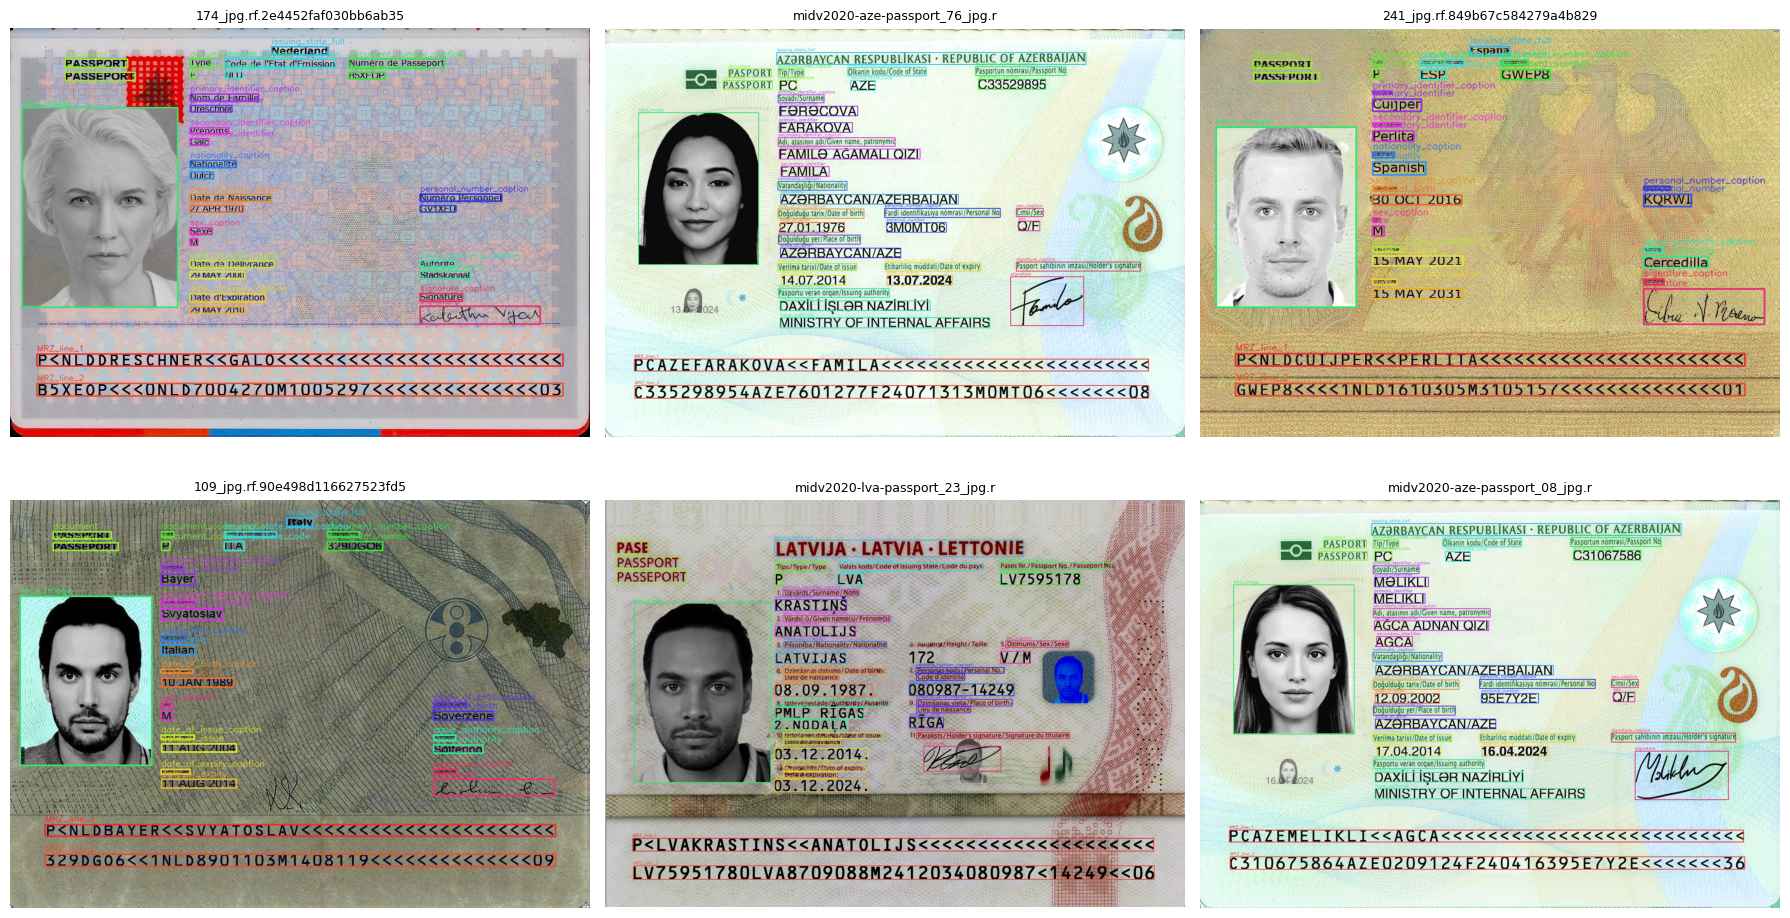

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Couleurs distinctes par classe (HSV → BGR)
def get_color(class_id, num_classes):
    hue = int(180 * class_id / max(1, num_classes))
    hsv = np.uint8([[[hue, 200, 230]]])
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)[0, 0]
    return tuple(int(c) for c in bgr)


def draw_yolo_annotations(img_path, lbl_path, class_names):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = [float(v) for v in parts[1:5]]
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)
            color = get_color(cls_id, len(class_names))
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = class_names[cls_id]
            cv2.putText(img, label, (x1, max(15, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


train_imgs = sorted((DATASET_DIR / "train" / "images").iterdir())
sample = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flat, sample):
    lbl_path = DATASET_DIR / "train" / "labels" / f"{img_path.stem}.txt"
    annotated = draw_yolo_annotations(img_path, lbl_path, CLASS_NAMES)
    if annotated is not None:
        ax.imshow(annotated)
    ax.axis("off")
    ax.set_title(img_path.name[:30], fontsize=9)
plt.tight_layout()
plt.show()


## 5. Entraînement YOLO11n

Choix :
- **YOLO11n** (nano, 2.6M params) : suffisant pour ~10 classes faciles, batch 32 tient en T4, training ~25 min
- **40 epochs** + early stopping (patience 12)
- Augmentations **doc-friendly** :
  - `fliplr=0.0` : pas de miroir horizontal (le texte ne survit pas)
  - `flipud=0.0` : pas de retournement vertical
  - `degrees=10` : rotations modérées (les docs sont parfois en biais en KYC mobile)
  - `mosaic=1.0` avec `close_mosaic=10` : mosaic activé sauf en fin pour stabiliser


In [9]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # weights COCO

results = model.train(
    data=str(DATA_YAML),
    epochs=40,
    imgsz=640,
    batch=32,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    patience=12,
    close_mosaic=10,
    # Augmentations doc-friendly
    fliplr=0.0,
    flipud=0.0,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.3,
    mixup=0.0,
    # Output
    project=str(RUNS),
    name="kyc_2_1_midv2020",
    exist_ok=True,
    save=True,
    plots=True,
    verbose=True,
)

BEST = RUNS / "kyc_2_1_midv2020" / "weights" / "best.pt"
print(f"\n✅ Best model : {BEST}")
print(f"   Taille : {BEST.stat().st_size / 1e6:.1f} MB")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 99.6MB/s]

New https://pypi.org/project/ultralytics/8.4.54 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/kyc/dataset/data.yaml, epochs=40, time=None, patience=12, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/kyc/runs, name=kyc_2_1_midv2020, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False

100%|██████████| 755k/755k [00:00<00:00, 34.1MB/s]


...

      40/40       4.8G     0.2922     0.2533     0.7952       1095        640: 100%|██████████| 140/140 [01:40<00:00,  1.39it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.01it/s]

                   all        160       5090      0.984      0.972      0.989      0.828



40 epochs completed in 1.245 hours.
Optimizer stripped from /content/kyc/runs/kyc_2_1_midv2020/weights/last.pt, 5.5MB
Optimizer stripped from /content/kyc/runs/kyc_2_1_midv2020/weights/best.pt, 5.5MB

Validating /content/kyc/runs/kyc_2_1_midv2020/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,588,587 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:06<00:00,  2.24s/it]


                   all        160       5090      0.984      0.972      0.989      0.828
            MRZ_line_1        160        160      0.911      0.988      0.989      0.494
            MRZ_line_2        160        160      0.661          1      0.924      0.495
         date_of_birth        160        160          1      0.996      0.995      0.919
 date_of_birth_caption        160        160          1      0.981      0.995      0.852
        date_of_expiry        160        160      0.992          1      0.995      0.918
date_of_expiry_caption        160        160      0.999      0.994      0.995      0.858
         date_of_issue        160        160      0.998          1      0.995      0.918
 date_of_issue_caption        160        160      0.998      0.975      0.985      0.846
              document        160        320          1      0.994      0.995      0.914
         document_code        160        160          1      0.783       0.97       0.76
 document_code_captio

## 6. Évaluation

Pour le KYC, les classes **critiques** sont `photo`/`face` et `date_of_expiry`. Si leur mAP@50 est < 0.85, le pipeline ne sera pas exploitable en prod et il faut soit augmenter le modèle (YOLO11s), soit ajouter des données.


In [10]:
model = YOLO(str(BEST))

val_metrics = model.val(data=str(DATA_YAML), split="val", plots=True)

print("\n=== VAL — global ===")
print(f"mAP@50     : {val_metrics.box.map50:.4f}")
print(f"mAP@50-95  : {val_metrics.box.map:.4f}")
print(f"Precision  : {val_metrics.box.mp:.4f}")
print(f"Recall     : {val_metrics.box.mr:.4f}")

print("\n=== mAP@50 par classe (val) ===")
try:
    ap50 = val_metrics.box.ap50
    for i, name in enumerate(CLASS_NAMES):
        if i < len(ap50):
            star = " ⭐" if name in ("photo", "face", "date_of_expiry") else ""
            print(f"  {name:30s} : {ap50[i]:.4f}{star}")
except Exception as e:
    print(f"   (impossible de lire ap50 par classe : {e})")


Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,588,587 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/kyc/dataset/valid/labels.cache... 160 images, 0 backgrounds, 0 corrupt: 100%|██████████| 160/160 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:10<00:00,  1.04s/it]


                   all        160       5090      0.985      0.972      0.989      0.833
            MRZ_line_1        160        160      0.912      0.988      0.989      0.495
            MRZ_line_2        160        160      0.693          1      0.922      0.492
         date_of_birth        160        160          1      0.996      0.995      0.922
 date_of_birth_caption        160        160          1      0.981      0.995      0.862
        date_of_expiry        160        160      0.992          1      0.995      0.939
date_of_expiry_caption        160        160      0.999      0.994      0.995      0.874
         date_of_issue        160        160      0.998          1      0.995      0.927
 date_of_issue_caption        160        160      0.998      0.975      0.985      0.855
              document        160        320          1      0.993      0.995      0.917
         document_code        160        160          1      0.781       0.97      0.764
 document_code_captio

In [11]:
# Test set (jamais vu pendant le training)
test_metrics = model.val(data=str(DATA_YAML), split="test", plots=True)

print("\n=== TEST ===")
print(f"mAP@50     : {test_metrics.box.map50:.4f}")
print(f"mAP@50-95  : {test_metrics.box.map:.4f}")
print(f"Precision  : {test_metrics.box.mp:.4f}")
print(f"Recall     : {test_metrics.box.mr:.4f}")


Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


val: Scanning /content/kyc/dataset/test/labels... 80 images, 0 backgrounds, 0 corrupt: 100%|██████████| 80/80 [00:00<00:00, 340.12it/s]

val: New cache created: /content/kyc/dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:08<00:00,  1.76s/it]


                   all         80       2534      0.983       0.97      0.988      0.839
            MRZ_line_1         80         80      0.907          1      0.987       0.51
            MRZ_line_2         80         80      0.699          1      0.931      0.517
         date_of_birth         80         80      0.996          1      0.995      0.931
 date_of_birth_caption         80         80          1       0.95      0.982      0.863
        date_of_expiry         80         80          1      0.996      0.995       0.94
date_of_expiry_caption         80         80      0.997          1      0.995      0.877
         date_of_issue         80         80      0.998          1      0.995      0.945
 date_of_issue_caption         80         80      0.998      0.975      0.988      0.863
              document         80        160          1       0.99      0.995      0.922
         document_code         80         80          1      0.747      0.976      0.748
 document_code_captio


=== results.png ===


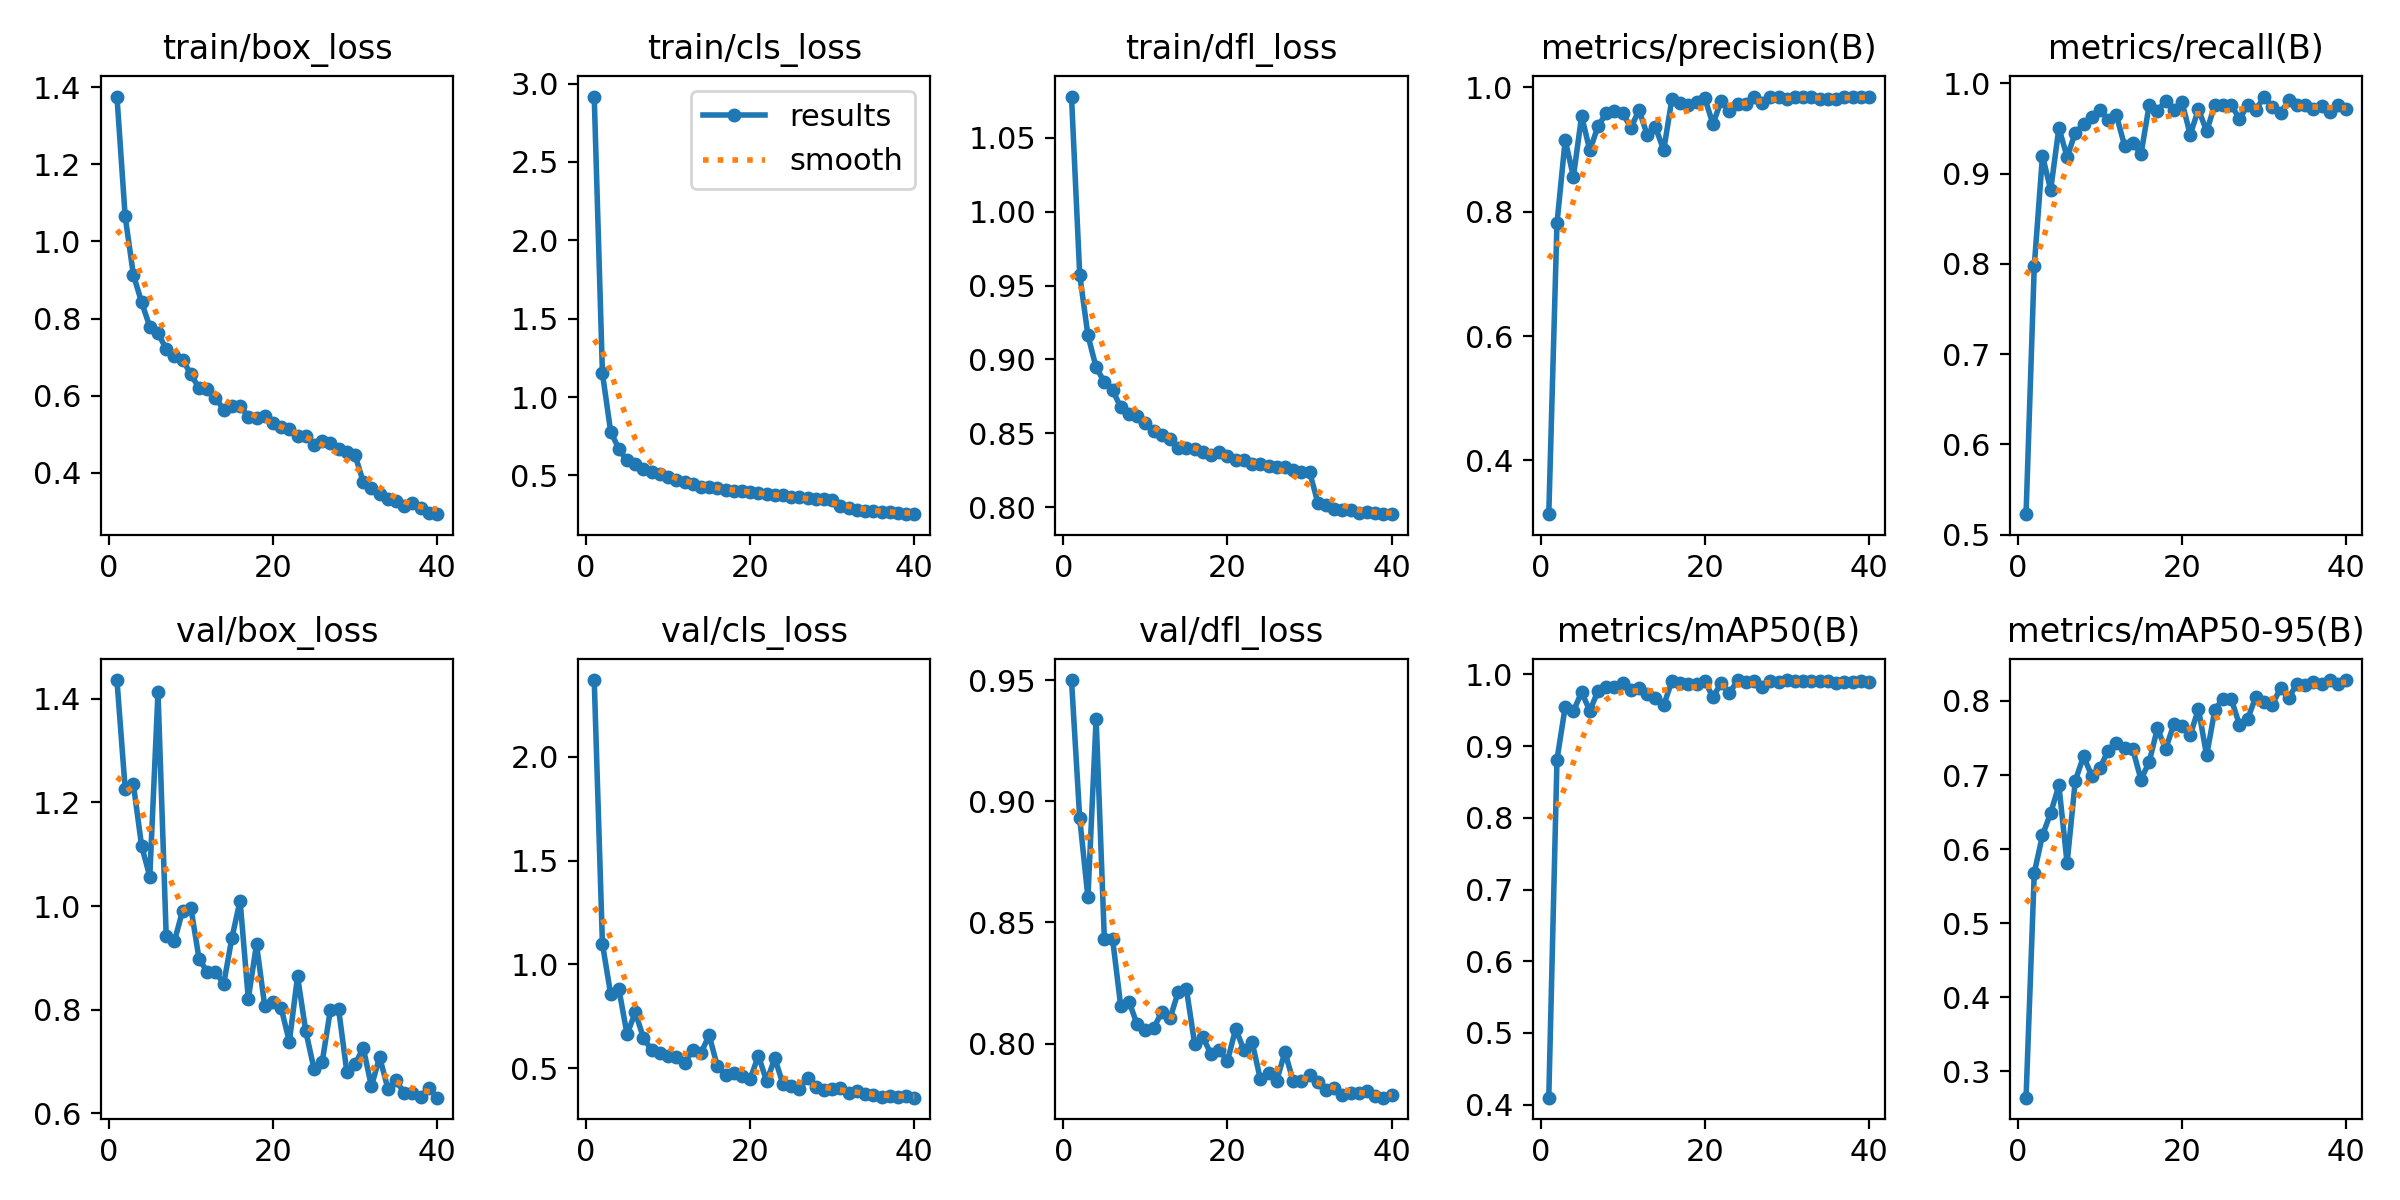


=== confusion_matrix.png ===


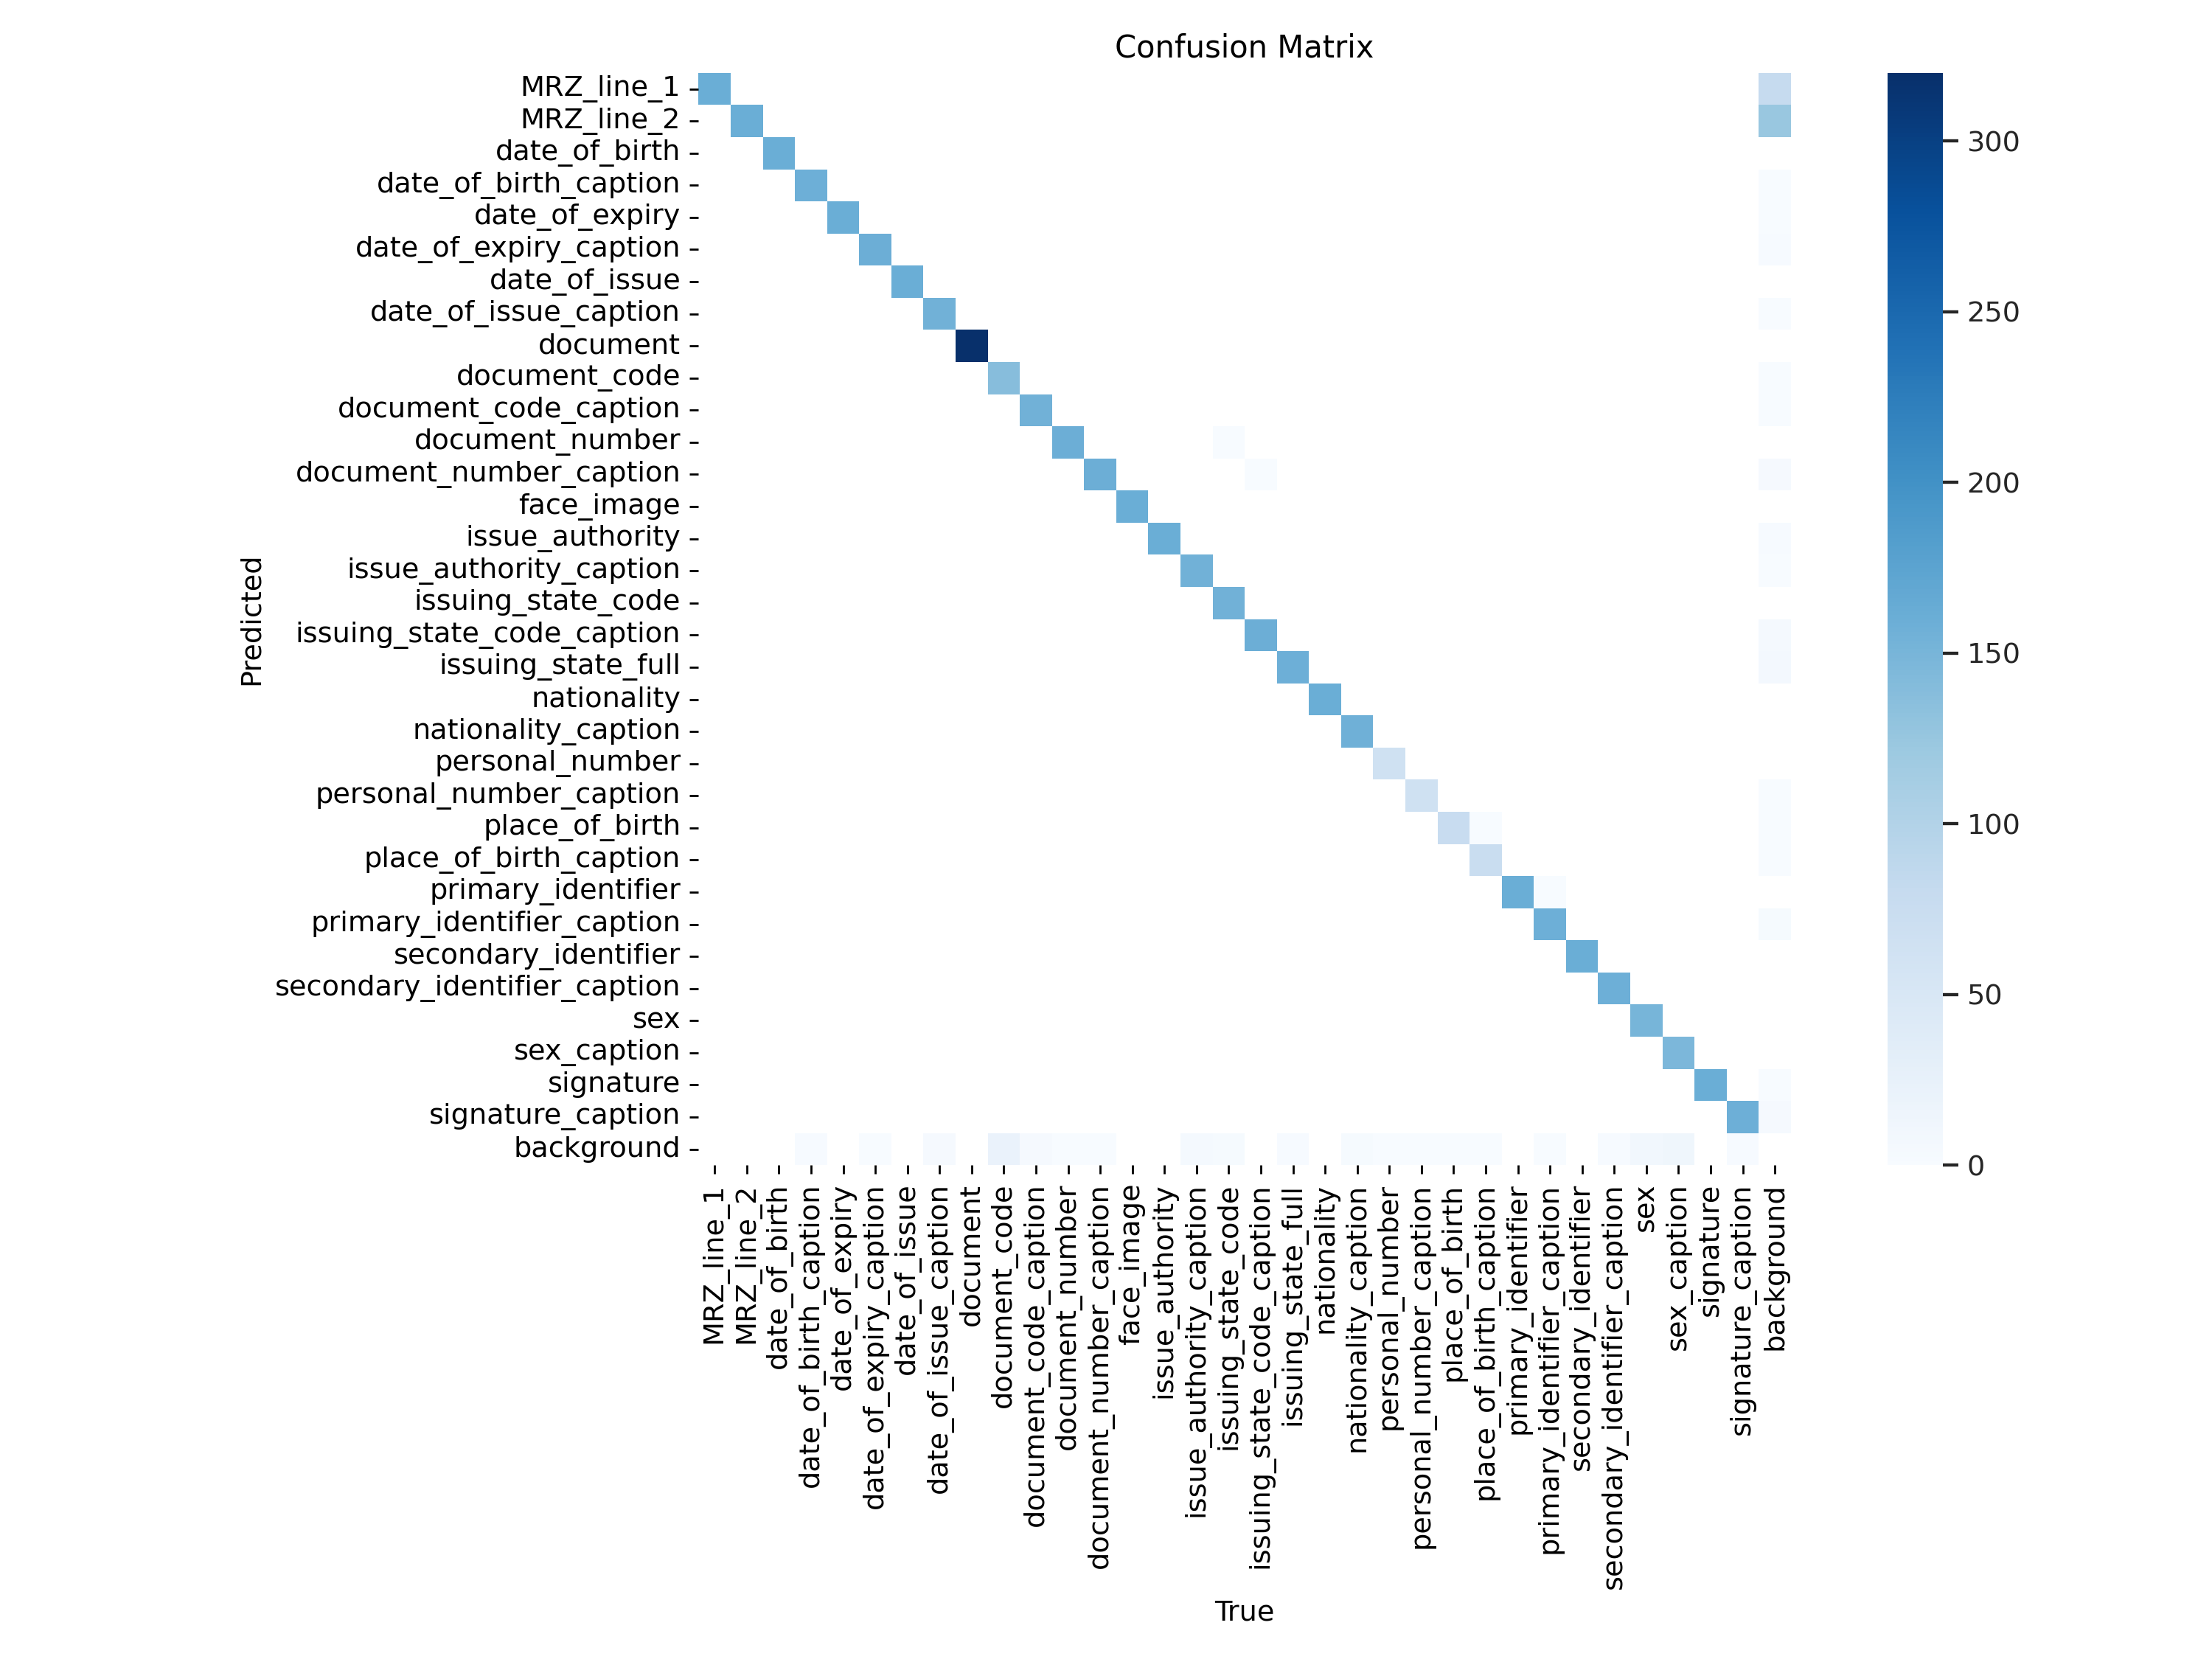


=== PR_curve.png ===


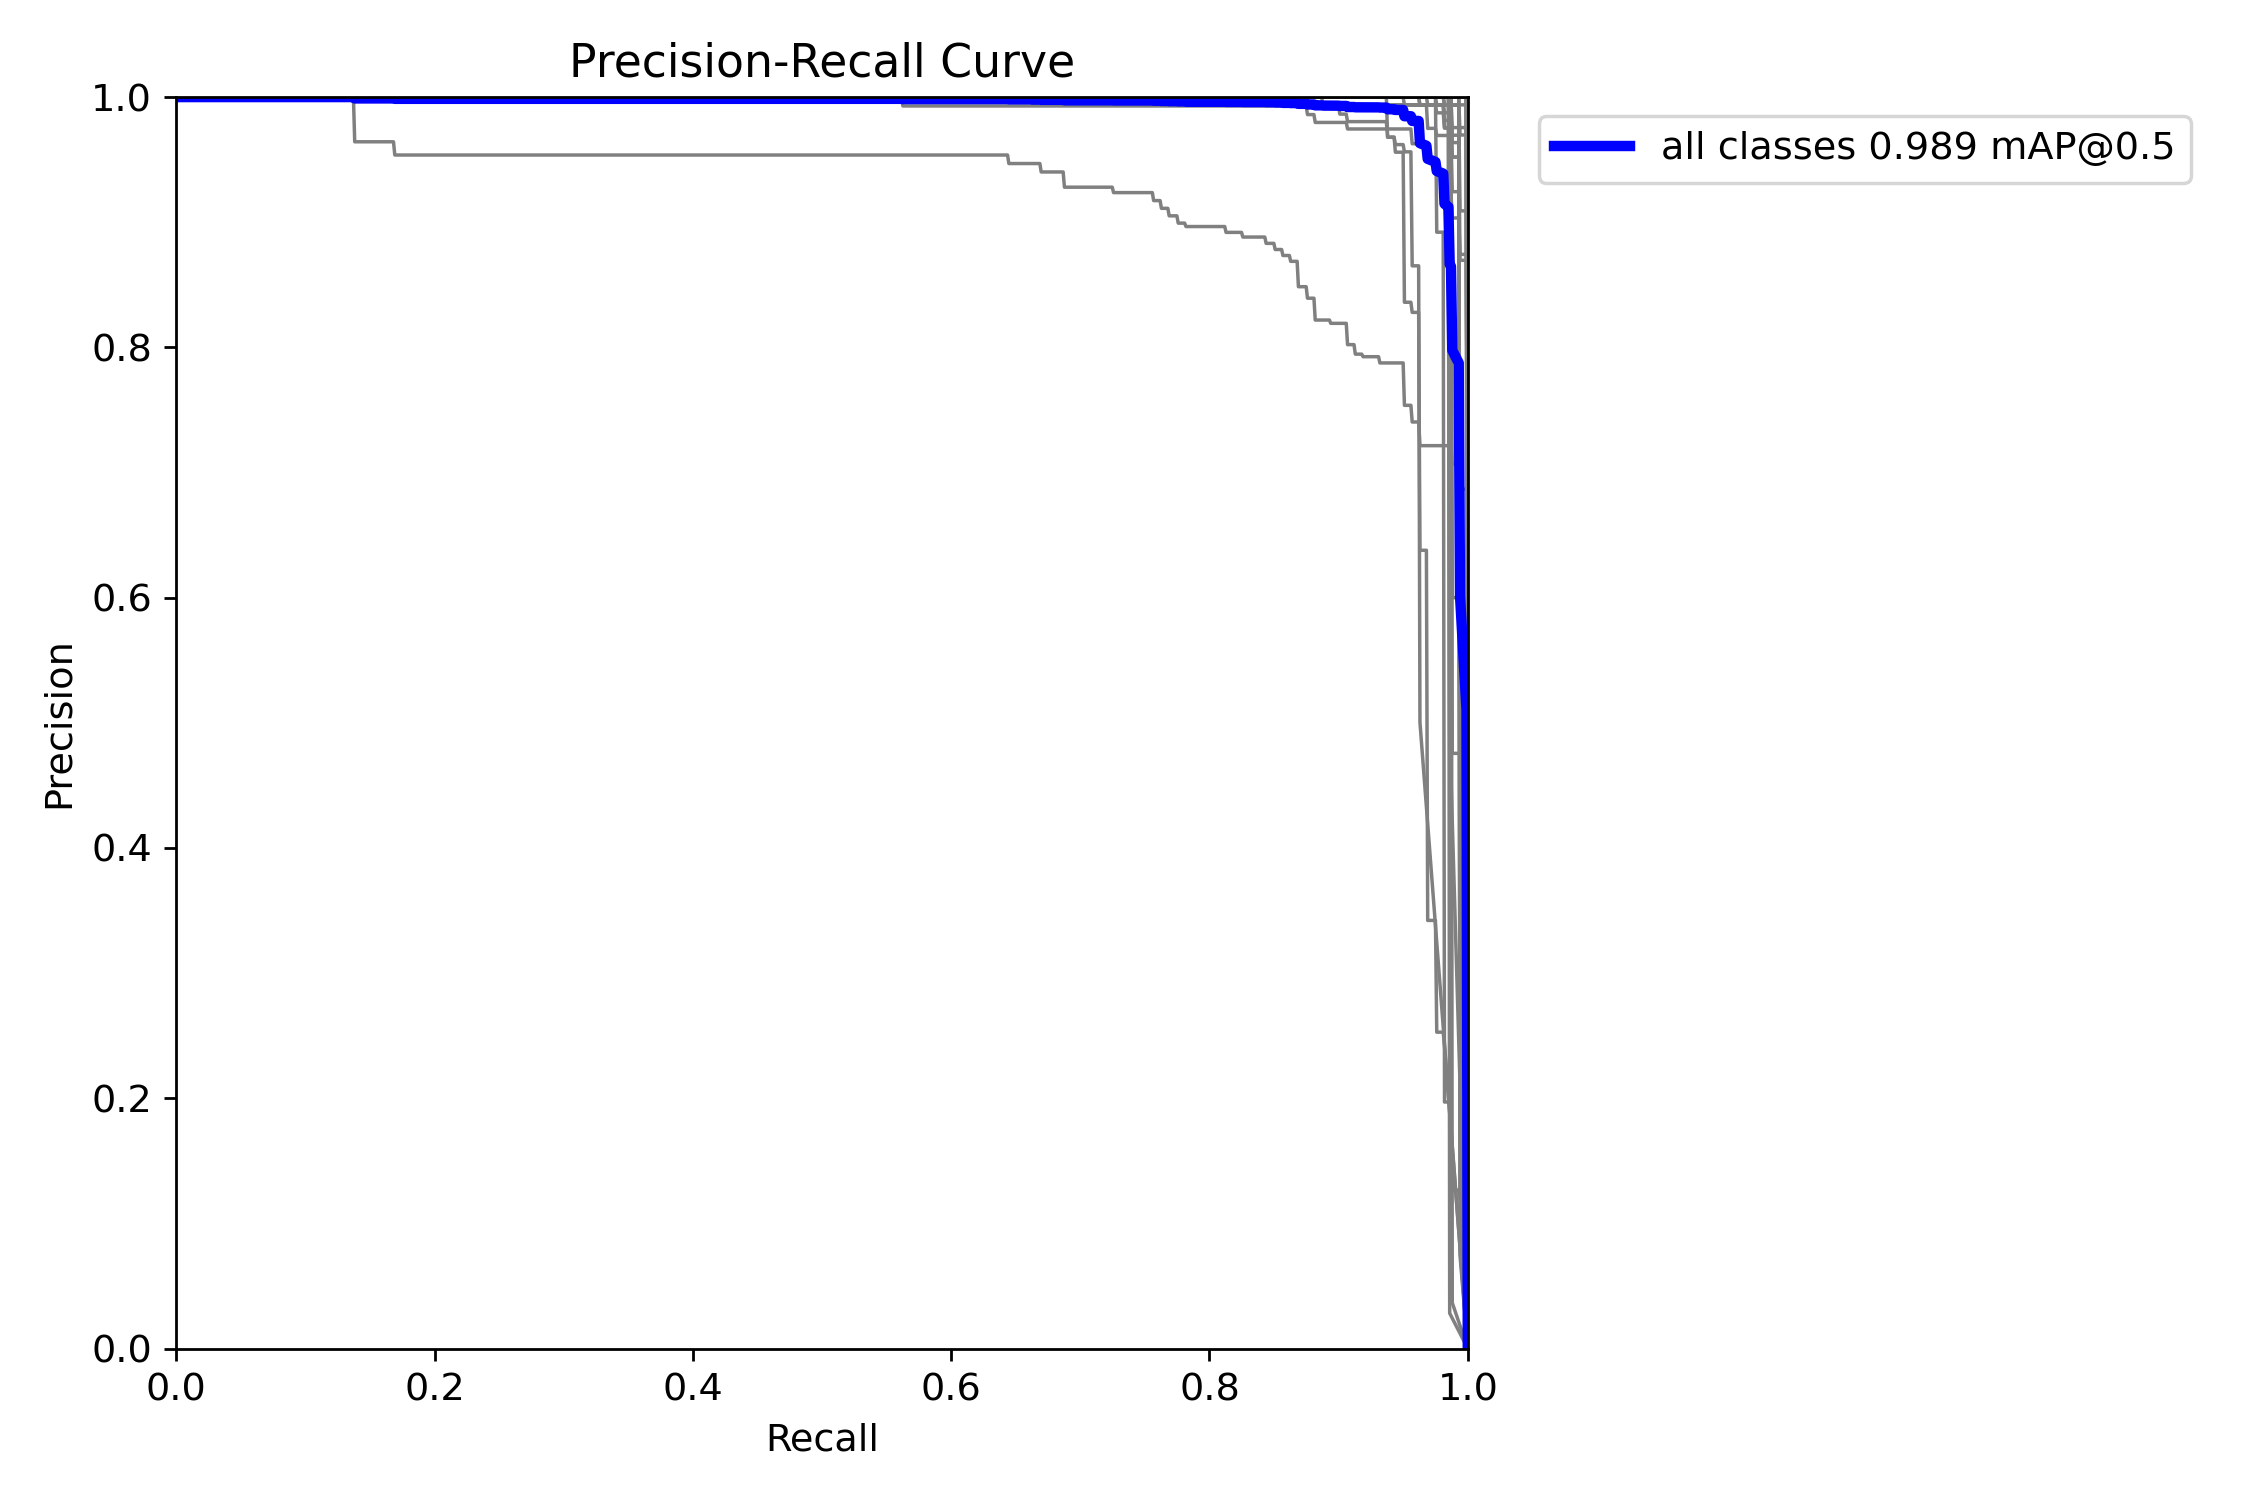


=== F1_curve.png ===


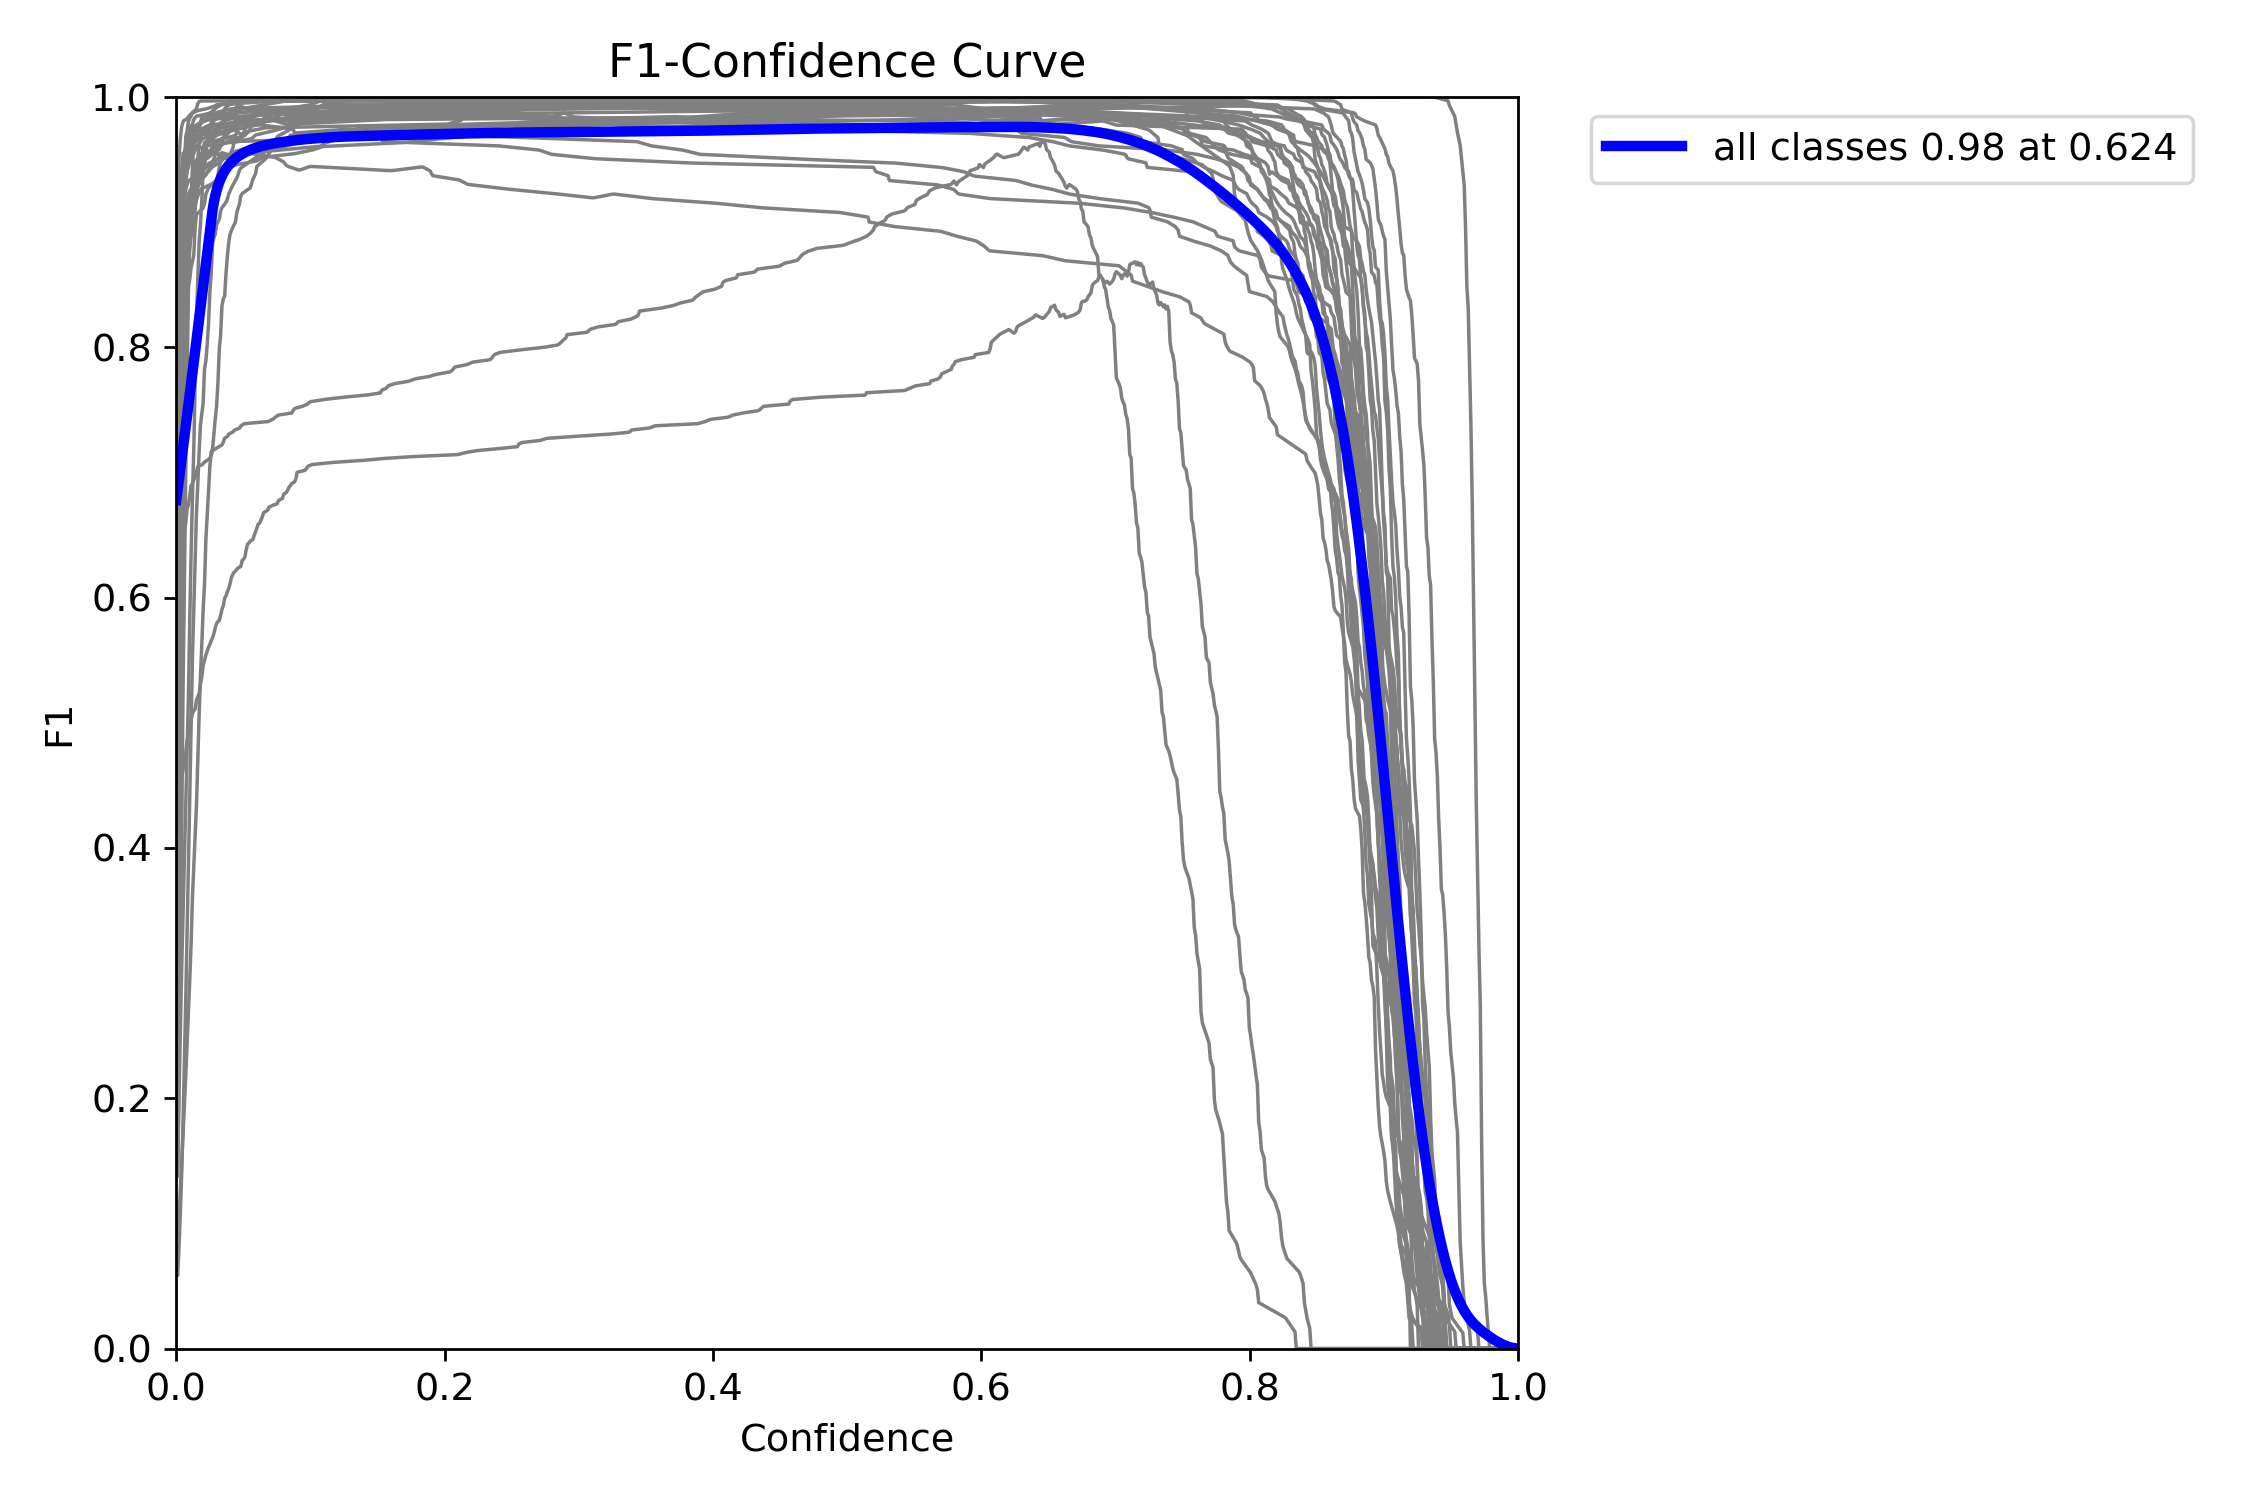

In [12]:
# Plots auto-générés
from IPython.display import Image as IPImage, display

run_dir = RUNS / "kyc_2_1_midv2020"
for fname in ("results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"):
    p = run_dir / fname
    if p.exists():
        print(f"\n=== {fname} ===")
        display(IPImage(str(p)))


## 7. Inférence visuelle sur le test set


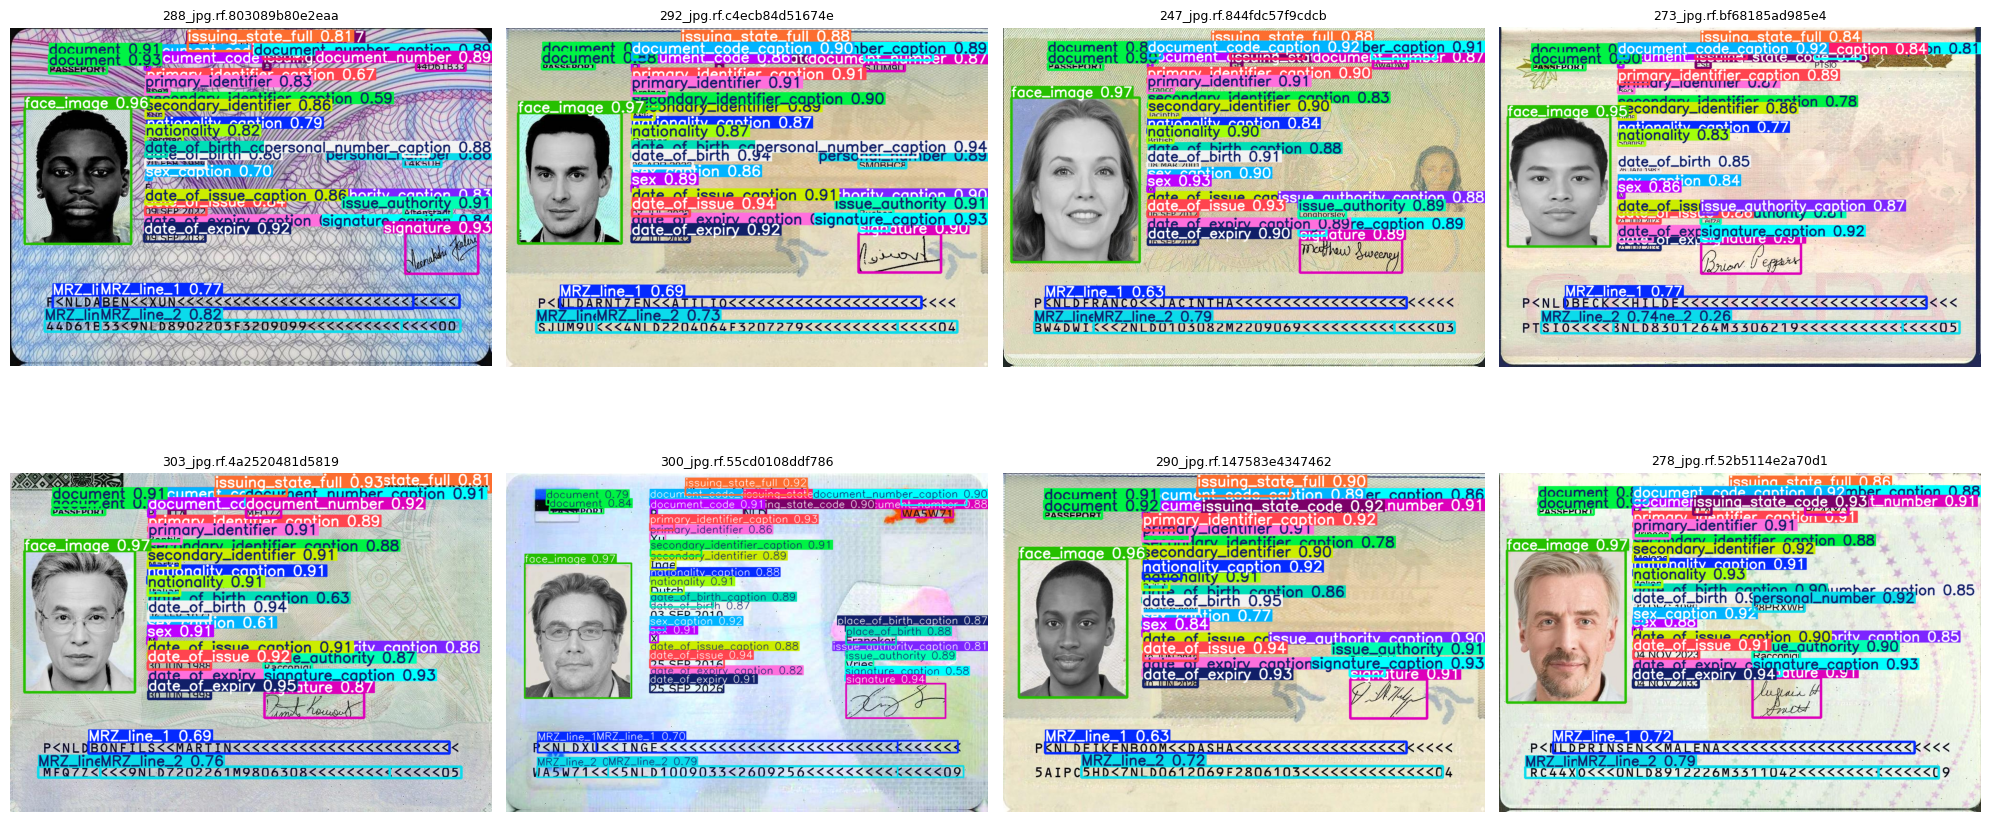

In [13]:
test_imgs = sorted((DATASET_DIR / "test" / "images").iterdir())
sample = random.sample(test_imgs, min(8, len(test_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, img_path in zip(axes.flat, sample):
    res = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    plotted = res.plot()  # BGR avec bboxes + labels
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    ax.set_title(img_path.stem[:25], fontsize=9)
plt.tight_layout()
plt.show()


## 8. API de production : `predict_and_crop()`

Renvoie un dict structuré avec tous les fields détectés. C'est l'interface vers l'étape 2.2 (face-match) et 3 (rapport légal).

Schema de sortie :
```python
{
    "image_path": str,
    "detections": {
        "<class_name>": {
            "bbox": [x1, y1, x2, y2],
            "conf": float,
            "crop_path": str,
        },
        ...
    },
    "kyc_critical": {
        "photo": {...} | None,           # input pour 2.2 face-match
        "date_of_expiry": {...} | None,  # à OCR ensuite pour le rapport
    },
    "missing_fields": [str],
}
```


In [19]:
PHOTO_ALIASES = {"photo", "face", "portrait", "photograph", "face_photo", "face_image"}
EXPIRY_ALIASES = {"date_of_expiry", "expiry_date", "expiration", "date_of_expiration", "expiry"}

photo_class = next((c for c in CLASS_NAMES if c.lower() in PHOTO_ALIASES), None)
expiry_class = next((c for c in CLASS_NAMES if c.lower() in EXPIRY_ALIASES), None)

print(f"📸 Classe photo identifiée : {photo_class}")
print(f"📅 Classe date_of_expiry identifiée : {expiry_class}")

📸 Classe photo identifiée : face_image
📅 Classe date_of_expiry identifiée : date_of_expiry


In [20]:
def predict_and_crop(image_path, output_dir="/content/kyc/crops",
                     conf_threshold=0.25, model_obj=None):
    """
    Détecte tous les fields d'un document d'identité et sauvegarde les crops.

    Returns
    -------
    dict avec image_path, detections, kyc_critical, missing_fields
    """
    mdl = model_obj if model_obj is not None else model
    image_path = Path(image_path)
    out_dir = Path(output_dir) / image_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    result = {
        "image_path": str(image_path),
        "detections": {},
        "kyc_critical": {"photo": None, "date_of_expiry": None},
        "missing_fields": [],
    }

    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        result["error"] = f"Image illisible : {image_path}"
        return result
    H, W = img_bgr.shape[:2]

    preds = mdl.predict(str(image_path), conf=conf_threshold, verbose=False)[0]

    for box in preds.boxes:
        cls_id = int(box.cls.item())
        cls_name = CLASS_NAMES[cls_id]
        conf = float(box.conf.item())
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)

        # Si une classe apparaît plusieurs fois, on garde la plus confiante
        if cls_name in result["detections"] and result["detections"][cls_name]["conf"] >= conf:
            continue

        crop = img_bgr[y1:y2, x1:x2]
        crop_path = out_dir / f"{cls_name}.jpg"
        cv2.imwrite(str(crop_path), crop, [cv2.IMWRITE_JPEG_QUALITY, 95])

        det = {
            "bbox": [x1, y1, x2, y2],
            "conf": round(conf, 4),
            "crop_path": str(crop_path),
        }
        result["detections"][cls_name] = det

        # Flag les fields critiques pour le KYC
        if cls_name == photo_class:
            result["kyc_critical"]["photo"] = det
        if cls_name == expiry_class:
            result["kyc_critical"]["date_of_expiry"] = det

    # Champs attendus mais non détectés
    expected = [c for c in CLASS_NAMES if c in ("document", photo_class, expiry_class) and c]
    result["missing_fields"] = [c for c in expected if c not in result["detections"]]

    return result


In [21]:
# Test sur 1 image
test_img = random.choice(list((DATASET_DIR / "test" / "images").iterdir()))
print(f"🖼️  Image : {test_img.name}\n")

res = predict_and_crop(test_img)

# Affichage succinct (sans les bboxes complets pour rester lisible)
print(f"Detections ({len(res['detections'])} classes) :")
for name, det in res["detections"].items():
    star = " ⭐" if name in (photo_class, expiry_class) else ""
    print(f"  - {name:30s} conf={det['conf']:.3f}{star}")

print(f"\nKYC critical fields :")
for k, v in res["kyc_critical"].items():
    status = "✅" if v else "❌"
    print(f"  {status} {k}")

print(f"\nMissing : {res['missing_fields']}")


🖼️  Image : 273_jpg.rf.bf68185ad985e487b7d2d38da07c892a.jpg

Detections (27 classes) :
  - face_image                     conf=0.952 ⭐
  - document_code_caption          conf=0.920
  - signature_caption              conf=0.916
  - signature                      conf=0.909
  - document                       conf=0.902
  - date_of_expiry_caption         conf=0.892
  - primary_identifier_caption     conf=0.889
  - date_of_expiry                 conf=0.878 ⭐
  - issue_authority_caption        conf=0.872
  - primary_identifier             conf=0.869
  - date_of_issue_caption          conf=0.858
  - secondary_identifier           conf=0.857
  - date_of_issue                  conf=0.856
  - sex                            conf=0.855
  - date_of_birth                  conf=0.854
  - issuing_state_full             conf=0.845
  - sex_caption                    conf=0.841
  - issuing_state_code_caption     conf=0.840
  - nationality                    conf=0.833
  - issue_authority                

📸 PHOTO (input étape 2.2 face-match) :


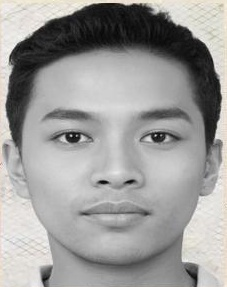


📅 DATE D'EXPIRATION (input étape 3 rapport légal, à OCR) :


In [22]:
# Afficher les crops critiques pour le KYC
from IPython.display import Image as IPImage, display

if res["kyc_critical"]["photo"]:
    print("📸 PHOTO (input étape 2.2 face-match) :")
    display(IPImage(res["kyc_critical"]["photo"]["crop_path"]))

if res["kyc_critical"]["date_of_expiry"]:
    print("\n📅 DATE D'EXPIRATION (input étape 3 rapport légal, à OCR) :")
    display(IPImage(res["kyc_critical"]["date_of_expiry"]["crop_path"]))


## 9. Règles de validation KYC

Avant de passer aux étapes suivantes, on flag les inputs douteux.


In [23]:
def validate_for_kyc(prediction_result):
    """
    Décision business à partir du résultat de predict_and_crop.

    Returns
    -------
    dict { status: 'OK' | 'REVIEW' | 'REJECTED', reasons: [str] }
    """
    out = {"status": "OK", "reasons": []}
    det = prediction_result.get("detections", {})
    crit = prediction_result.get("kyc_critical", {})

    # Aucune détection = rejet direct
    if not det:
        return {"status": "REJECTED",
                "reasons": ["Aucun champ détecté — image non conforme"]}

    # Photo absente = rejet (impossible de faire l'étape 2.2)
    if not crit.get("photo"):
        out["status"] = "REJECTED"
        out["reasons"].append("CRITIQUE : photo du porteur non détectée → face-match impossible")
        return out

    # Photo détectée mais confiance faible
    if crit["photo"]["conf"] < 0.6:
        out["status"] = "REVIEW"
        out["reasons"].append(f"Photo détectée avec faible confiance ({crit['photo']['conf']:.2f})")

    # Date d'expiration absente = review (on peut quand même tenter 2.2 mais le rapport sera incomplet)
    if not crit.get("date_of_expiry"):
        out["reasons"].append("Date d'expiration non détectée — rapport incomplet")
        out["status"] = "REVIEW" if out["status"] == "OK" else out["status"]

    # Confiance moyenne sur l'ensemble des détections
    if det:
        mean_conf = sum(d["conf"] for d in det.values()) / len(det)
        if mean_conf < 0.65:
            out["reasons"].append(f"Confiance moyenne faible ({mean_conf:.2f}) — image probablement floue")
            out["status"] = "REVIEW" if out["status"] == "OK" else out["status"]

    return out


verdict = validate_for_kyc(res)
print(json.dumps(verdict, indent=2, ensure_ascii=False))


{
  "status": "OK",
  "reasons": []
}


## 10. Export pour déploiement


In [24]:
!pip install -q onnxscript

# ONNX (CPU / mobile / edge)
model.export(format="onnx", imgsz=640, opset=12)

# TorchScript (PyTorch standalone)
model.export(format="torchscript", imgsz=640)

weights_dir = BEST.parent
print("\n📦 Artefacts dans", weights_dir)
for f in sorted(weights_dir.iterdir()):
    print(f"  {f.name:30s} {f.stat().st_size / 1e6:7.1f} MB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.7 MB/s eta 0:00:00
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from '/content/kyc/runs/kyc_2_1_midv2020/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 37, 8400) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 12...


W0526 12:43:48.994000 1437 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0526 12:43:49.788000 1437 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0526 12:43:49.790000 1437 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio

ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 6.7s, saved as '/content/kyc/runs/kyc_2_1_midv2020/weights/best.onnx' (10.0 MB)

Export complete (7.0s)
Results saved to /content/kyc/runs/kyc_2_1_midv2020/weights
Predict:         yolo predict task=detect model=/content/kyc/runs/kyc_2_1_midv2020/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/kyc/runs/kyc_2_1_midv2020/weights/best.onnx imgsz=640 data=/content/kyc/dataset/data.yaml  
Visualize:       https://netron.app
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from '/content/kyc/runs/kyc_2_1_midv2020/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 37, 8400) (5.2 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 2.2s, saved as '/content/kyc/runs/kyc_2_1_midv2020/weights/best.torchscript' (10.4 MB)

Export complete (2.5s)
Results saved to /content/kyc/runs/kyc_2_1_

## 11. Bilan + Soutenance

### Artefacts livrés
| Artefact | Chemin | Utilité |
|---|---|---|
| `best.pt` | `runs/kyc_2_1_midv2020/weights/best.pt` | Modèle PyTorch |
| `best.onnx` | idem `.onnx` | Déployable CPU/edge |
| `predict_and_crop()` | dans ce notebook | API → étapes 2.2 et 3 |
| `validate_for_kyc()` | dans ce notebook | Règles métier KYC |
| Plots | `runs/kyc_2_1_midv2020/` | Pour le rapport |

### Choix à défendre en soutenance

**1. Dataset : GenMRP+MIDV-2020 plutôt que MIDV-2020 pur**
- La source officielle MIDV-2020 (Univ La Rochelle, 124 GB, sFTP + formulaire) n'est pas exploitable en Colab dans un timing réaliste
- Le mix GenMRP+MIDV-2020 (Maastricht) est **un superset** : MIDV-2020 + passeports synthétiques → plus de variabilité → meilleure généralisation en prod
- Format YOLO direct → pas de bugs de conversion d'annotations

**2. Modèle : YOLO11n et pas YOLO11s**
- YOLO11n (2.6M params) suffit pour ~10 classes faciles (photo, dates, signature… objets bien délimités)
- Inférence 3× plus rapide → critique pour KYC mobile temps-réel
- Si la perf n'est pas au rendez-vous : `model = YOLO("yolo11s.pt")` + relancer (×3 params, +5% mAP attendus)

**3. Augmentations doc-aware**
- `fliplr=0.0` : le texte ne survit pas au miroir horizontal
- `degrees=10` : les docs sont souvent légèrement en biais en KYC mobile, on entraîne le modèle à le gérer
- `mosaic` désactivé sur les 10 dernières epochs pour stabiliser la fin du training

**4. API métier : `predict_and_crop` + `validate_for_kyc`**
- Interface stable indépendante du modèle sous-jacent
- Les coéquipiers/code de l'étape 2.2 et 3 n'ont pas besoin de savoir que c'est YOLO derrière
- Détection automatique des aliases de classes (`photo`/`face`/`portrait`, `date_of_expiry`/`expiry_date`…) → portable si on change de dataset

### Pour aller plus loin (bonus)
- **TTA (Test-Time Augmentation)** : `model.val(augment=True)` → +1-2 pts mAP gratos
- **OCR sur les crops** : combiner avec Tesseract ou PaddleOCR pour extraire le texte des dates → utile pour l'étape 3 (rapport légal)
- **Pipeline 2-stages** : ajouter un YOLO upstream (MIDV-500) pour localiser+rectifier le doc avant détection field-level → gain de +5-8 pts mAP attendu
- **Active learning** : logger les détections `conf < 0.5` en prod pour réannotation humaine
